Import Libraries

In [1]:
import tensorflow as tensorflow
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

Load MNIST Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Shape of dataset

In [3]:
print(x_train.shape)

(60000, 28, 28)


Visualize Sample Image

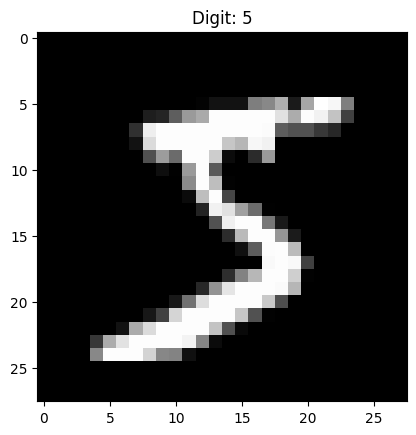

In [4]:
plt.imshow(x_train[0],cmap="gray")
plt.title("Digit: "+str(y_train[0]))
plt.show()

# Data Preprocessing

Normalizing Data

In [5]:
x_train=x_train/255.0
x_test=x_test/255.0

Reshape for CNN

In [6]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)


Build CNN model

In [7]:
model = keras.models.Sequential([
    keras.layers.Conv2D(32,(3,3), activation='relu',input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64,(3,3), activation ='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Training Model

In [9]:
model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9593 - loss: 0.1309 - val_accuracy: 0.9854 - val_loss: 0.0441
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9865 - loss: 0.0432 - val_accuracy: 0.9901 - val_loss: 0.0340
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9904 - loss: 0.0299 - val_accuracy: 0.9893 - val_loss: 0.0313
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9934 - loss: 0.0219 - val_accuracy: 0.9897 - val_loss: 0.0321
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9891 - val_loss: 0.0366


Evaluate Model

In [10]:
total_loss,test_acc = model.evaluate(x_test,y_test)
print("Test accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9891 - loss: 0.0366
Test accuracy:  0.9890999794006348


Save Trained Model

In [12]:
model.save("mnist_model.h5")

Upload Image

In [29]:
from google.colab import files
uploaded = files.upload()

Saving digit6.png to digit6.png


Load Image

In [23]:
from PIL import Image

Preprocess the Image

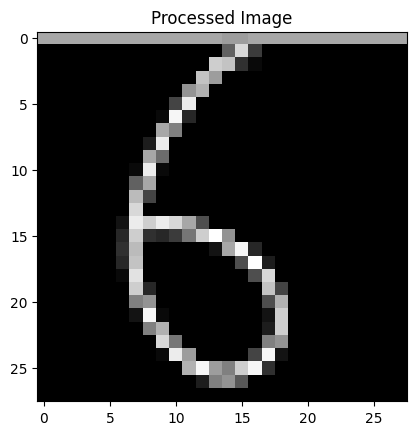

In [30]:
img = Image.open("digit6.png").convert("L")
img = img.resize((28,28))

img_array = np.array(img)

img_array = 255 - img_array

img_array = img_array / 255.0

plt.imshow(img_array, cmap="gray")
plt.title("Processed Image")
plt.show()

Prepare for Model Input

In [31]:
img_array = img_array.reshape(1,28,28,1)

Predict Digit

In [32]:
from tensorflow import keras

model = keras.models.load_model("mnist_model.h5")

prediction = model.predict(img_array)

digit = np.argmax(prediction)

print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Digit: 1
